In [1]:
#Load and inspect
import pandas as pd
df = pd.read_csv('/content/2009.csv')
df.info()
df.head()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 979082 entries, 0 to 979081
Data columns (total 28 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   FL_DATE              979082 non-null  object 
 1   OP_CARRIER           979082 non-null  object 
 2   OP_CARRIER_FL_NUM    979082 non-null  int64  
 3   ORIGIN               979082 non-null  object 
 4   DEST                 979082 non-null  object 
 5   CRS_DEP_TIME         979082 non-null  int64  
 6   DEP_TIME             961949 non-null  float64
 7   DEP_DELAY            961949 non-null  float64
 8   TAXI_OUT             961440 non-null  float64
 9   WHEELS_OFF           961440 non-null  float64
 10  WHEELS_ON            960594 non-null  float64
 11  TAXI_IN              960595 non-null  float64
 12  CRS_ARR_TIME         979081 non-null  float64
 13  ARR_TIME             960594 non-null  float64
 14  ARR_DELAY            959155 non-null  float64
 15  CANCELLED        

,0
FL_DATE,0
OP_CARRIER,0
OP_CARRIER_FL_NUM,0
ORIGIN,0
DEST,0
CRS_DEP_TIME,0
DEP_TIME,17133
DEP_DELAY,17133
TAXI_OUT,17642
WHEELS_OFF,17642


In [2]:
#Clean and transform
# Drop rows with missing arrival delay (can't analyze what we don't have)
df = df.dropna(subset=['ARR_DELAY'])

# Convert date column
df['FL_DATE'] = pd.to_datetime(df['FL_DATE'])

# Standardize codes
df['OP_CARRIER'] = df['OP_CARRIER'].str.strip().str.upper()
df['ORIGIN'] = df['ORIGIN'].str.strip().str.upper()

# Create a delayed flag (industry standard: >15 min late)
df['DELAYED'] = (df['ARR_DELAY'] > 15).astype(int)

df[['FL_DATE','OP_CARRIER','ORIGIN','ARR_DELAY','DELAYED']].head()

,FL_DATE,OP_CARRIER,ORIGIN,ARR_DELAY,DELAYED
0,2009-01-01,XE,DCA,4.0,0
1,2009-01-01,XE,EWR,-8.0,0
2,2009-01-01,XE,EWR,-9.0,0
3,2009-01-01,XE,DCA,-12.0,0
4,2009-01-01,XE,IAD,-38.0,0


In [3]:
#Exploratory Data Analysis (EDA)
# Average delay by airline
avg_delay_by_airline = df.groupby('OP_CARRIER')['ARR_DELAY'].mean().sort_values(ascending=False)
avg_delay_by_airline

,ARR_DELAY
OP_CARRIER,
OH,12.667358
EV,7.597953
AS,7.568416
YV,7.505257
CO,6.914554
MQ,6.257993
F9,5.165948
OO,4.995881
NW,4.659017


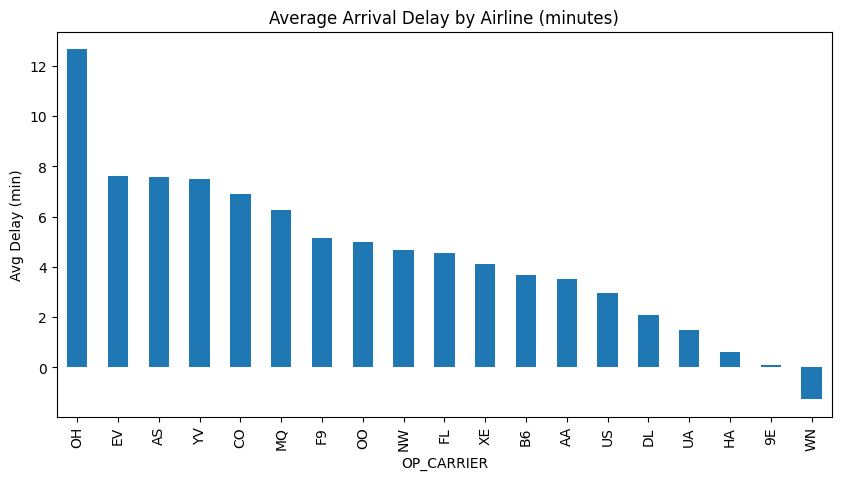

In [4]:
import matplotlib.pyplot as plt

avg_delay_by_airline.plot(kind='bar', figsize=(10,5), title='Average Arrival Delay by Airline (minutes)')
plt.ylabel('Avg Delay (min)')
plt.show()

In [6]:
#SQL analysis with window functions (SQLite, in-memory)
import sqlite3

conn = sqlite3.connect(':memory:')
df.to_sql('flights', conn, index=False, if_exists='replace')

query = """
SELECT OP_CARRIER, ORIGIN,
       AVG(ARR_DELAY) AS avg_delay,
       RANK() OVER (PARTITION BY OP_CARRIER ORDER BY AVG(ARR_DELAY) DESC) AS rnk
FROM flights
GROUP BY OP_CARRIER, ORIGIN
"""
result = pd.read_sql(query, conn)
result[result['rnk'] <= 3].head(20)  # top 3 worst-delay airports per airline

,OP_CARRIER,ORIGIN,avg_delay,rnk
0,9E,MIA,42.500000,1
1,9E,MHT,25.333333,2
2,9E,ALO,20.150000,3
119,AA,LIH,21.527273,1
120,AA,KOA,21.089286,2
121,AA,GUC,20.523810,3
197,AS,JNU,25.213740,1
198,AS,EWR,24.727273,2
199,AS,PSG,22.545455,3
243,B6,EWR,18.361613,1


In [8]:
#Export the cleaned dataset for Power BI
from google.colab import files
df.to_csv('cleaned_flights.csv', index=False)
files.download('cleaned_flights.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>